# Fort Collins Levy Policy Example

This notebook uses the same general narrative structure as the Baltimore and Cleveland examples, adapted to Larimer County's parcel data for Fort Collins, Colorado.


In [1]:
import os
import sys
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "lvt_utils.py").exists():
    REPO_ROOT = REPO_ROOT.parent

if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

from lvt_utils import calculate_category_tax_summary
from census_utils import get_census_data_with_boundaries, match_to_census_blockgroups
from policy_analysis import analyze_vacant_land, analyze_land_by_improvement_share
from viz import (
    calculate_block_group_summary,
    create_quintile_summary,
    create_spokane_property_category_chart,
    create_threshold_change_chart,
    filter_data_for_analysis,
    plot_upside_down_quintile_bars,
)

load_dotenv(REPO_ROOT / ".env")
sns.set_theme(style="white")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)

ACCOUNT_URL = "https://storage.googleapis.com/lc-public/asr/assessor-public-account.csv"
VALUE_URL = "https://storage.googleapis.com/lc-public/asr/assessor-public-value-detail.csv"
GEOMETRY_URL = "zip+https://apps.larimer.org/api/gis/files/GIS_ParcelOwnerSHP.zip"


In [2]:
data_dir = REPO_ROOT / "examples" / "data" / "fort_collins"
data_dir.mkdir(parents=True, exist_ok=True)
data_dir


PosixPath('/Users/gregmiller/Documents/CLE/cle/LVTShift/examples/data/fort_collins')

## Step 1: Load Parcel Data

The account table gives parcel location, tax area, and levy fields. The value-detail table gives `Land` and `Improvement` rows with actual value plus separate assessed-value bases for local and school levies.


In [3]:
parcel_attrs = pd.read_csv(
    ACCOUNT_URL,
    usecols=[
        "SCHEDULENUM",
        "PARCELNO",
        "TAXAREA",
        "ACCTTYPE",
        "APPRAISALTYPE",
        "SITUSADDRESS",
        "SITUSCITY",
        "SITUSZIPCODE",
        "LGMILLLEVY",
        "SCHOOLMILLLEVY",
        "TOTALMILLLEVY",
        "TAXYEAR",
        "RUNDATE",
    ],
)

fort_collins = parcel_attrs[
    (parcel_attrs["APPRAISALTYPE"] == "Real")
    & (parcel_attrs["SITUSCITY"] == "FORT COLLINS")
].copy()

print(f"Total Fort Collins parcels: {len(fort_collins):,}")
fort_collins.head()


Total Fort Collins parcels: 71,408


,PARCELNO,SCHEDULENUM,TAXAREA,ACCTTYPE,APPRAISALTYPE,SITUSADDRESS,SITUSCITY,SITUSZIPCODE,LGMILLLEVY,SCHOOLMILLLEVY,TOTALMILLLEVY,TAXYEAR,RUNDATE
1,6.120000e+08,1147439,1000,Residential,Real,5594 OVERHILL DR,FORT COLLINS,80526.0,40.448,54.09,94.538,2025,2026-01-13 12:03:33
2,6.120001e+08,1422081,1000,Agricultural,Real,5590 OVERHILL DR,FORT COLLINS,80526.0,40.448,54.09,94.538,2025,2026-01-13 12:03:33
4,6.120001e+08,1589991,1000,Residential,Real,5586 OVERHILL DR,FORT COLLINS,80526.0,40.448,54.09,94.538,2025,2026-01-13 12:03:33
5,6.120001e+08,1616855,1000,Agricultural,Real,5585 OVERHILL DR,FORT COLLINS,80526.0,40.448,54.09,94.538,2025,2026-01-13 12:03:33
108,8.610001e+09,1612700,1000,Exempt,Real,4433 E COUNTY ROAD 34E,FORT COLLINS,80528.0,40.448,54.09,94.538,2025,2026-01-13 12:03:33


In [4]:
fc_sched = set(fort_collins["SCHEDULENUM"].astype(int).tolist())

value_parts = []
for chunk in pd.read_csv(
    VALUE_URL,
    usecols=["SCHEDULENUM", "VALUETYPE", "ACTUALVALUE", "LG_ASDVALUE", "SCHOOL_ASDVALUE"],
    chunksize=250000,
):
    chunk = chunk[chunk["SCHEDULENUM"].isin(fc_sched)]
    if len(chunk):
        value_parts.append(
            chunk.groupby(["SCHEDULENUM", "VALUETYPE"], dropna=False)[
                ["ACTUALVALUE", "LG_ASDVALUE", "SCHOOL_ASDVALUE"]
            ]
            .sum()
            .reset_index()
        )

value_detail = (
    pd.concat(value_parts, ignore_index=True)
    .groupby(["SCHEDULENUM", "VALUETYPE"], dropna=False)[["ACTUALVALUE", "LG_ASDVALUE", "SCHOOL_ASDVALUE"]]
    .sum()
    .reset_index()
)

value_pivot = value_detail.pivot(
    index="SCHEDULENUM",
    columns="VALUETYPE",
    values=["ACTUALVALUE", "LG_ASDVALUE", "SCHOOL_ASDVALUE"],
).fillna(0)
value_pivot.columns = [f"{a.lower()}_{b.lower()}" for a, b in value_pivot.columns]
value_pivot = value_pivot.reset_index().rename(
    columns={
        "actualvalue_land": "land_actual_value",
        "actualvalue_improvement": "improvement_actual_value",
        "lg_asdvalue_land": "land_lg_asd",
        "lg_asdvalue_improvement": "improvement_lg_asd",
        "school_asdvalue_land": "land_school_asd",
        "school_asdvalue_improvement": "improvement_school_asd",
    }
)

for col in [
    "land_actual_value",
    "improvement_actual_value",
    "land_lg_asd",
    "improvement_lg_asd",
    "land_school_asd",
    "improvement_school_asd",
]:
    if col not in value_pivot.columns:
        value_pivot[col] = 0.0

fort_collins = fort_collins.merge(value_pivot, on="SCHEDULENUM", how="left").fillna(0)
fort_collins["total_actual_value"] = fort_collins["land_actual_value"] + fort_collins["improvement_actual_value"]
fort_collins["land_share_actual"] = np.where(
    fort_collins["total_actual_value"] > 0,
    fort_collins["land_actual_value"] / fort_collins["total_actual_value"],
    np.nan,
)

fort_collins.head()


,PARCELNO,SCHEDULENUM,TAXAREA,ACCTTYPE,APPRAISALTYPE,SITUSADDRESS,SITUSCITY,SITUSZIPCODE,LGMILLLEVY,SCHOOLMILLLEVY,TOTALMILLLEVY,TAXYEAR,RUNDATE,improvement_actual_value,land_actual_value,improvement_lg_asd,land_lg_asd,improvement_school_asd,land_school_asd,total_actual_value,land_share_actual
0,6.120000e+08,1147439,1000,Residential,Real,5594 OVERHILL DR,FORT COLLINS,80526.0,40.448,54.09,94.538,2025,2026-01-13 12:03:33,289100.0,550000.0,18069.0,34375.0,20382.0,38775.0,839100.0,0.655464
1,6.120001e+08,1422081,1000,Agricultural,Real,5590 OVERHILL DR,FORT COLLINS,80526.0,40.448,54.09,94.538,2025,2026-01-13 12:03:33,950600.0,780.0,60201.0,211.0,67775.0,211.0,951380.0,0.000820
2,6.120001e+08,1589991,1000,Residential,Real,5586 OVERHILL DR,FORT COLLINS,80526.0,40.448,54.09,94.538,2025,2026-01-13 12:03:33,845000.0,550000.0,52813.0,34375.0,59573.0,38775.0,1395000.0,0.394265
3,6.120001e+08,1616855,1000,Agricultural,Real,5585 OVERHILL DR,FORT COLLINS,80526.0,40.448,54.09,94.538,2025,2026-01-13 12:03:33,96200.0,450.0,25974.0,122.0,25974.0,122.0,96650.0,0.004656
4,8.610001e+09,1612700,1000,Exempt,Real,4433 E COUNTY ROAD 34E,FORT COLLINS,80528.0,40.448,54.09,94.538,2025,2026-01-13 12:03:33,539800.0,79300.0,145746.0,21411.0,145746.0,21411.0,619100.0,0.128089


## Step 2: Prepare Fort Collins Parcels for Modeling

The existing examples use a common property-category field for summaries and charts. Here we create a Fort Collins version from `ACCTTYPE` and the parcel's land/improvement pattern.


In [5]:
def categorize_fort_collins_property(row):
    if row["improvement_actual_value"] == 0 and row["land_actual_value"] > 0:
        return "Vacant Land"
    acct = row["ACCTTYPE"]
    if acct == "Residential":
        return "Single Family Residential"
    if acct == "Multiple Unit":
        return "Multi-Family Residential"
    if acct == "Mobile Home":
        return "Mobile Home"
    if acct == "MH Park":
        return "Mobile Home Park"
    if acct in {"Commercial", "PI Comm"}:
        return "Commercial / Mixed Use"
    if acct == "Industrial":
        return "Industrial"
    if acct == "Agricultural":
        return "Agricultural"
    if acct in {"Exempt", "Partial Exempt"}:
        return "Institutional / Exempt"
    if acct == "Nat Resources":
        return "Natural Resources"
    return "Other"


fort_collins["PROPERTY_CATEGORY"] = fort_collins.apply(categorize_fort_collins_property, axis=1)

fort_collins["PROPERTY_CATEGORY"].value_counts().rename_axis("PROPERTY_CATEGORY").to_frame("count")


,count
PROPERTY_CATEGORY,
Single Family Residential,59565
Mobile Home,3563
Commercial / Mixed Use,2916
Vacant Land,2771
Multi-Family Residential,1193
Institutional / Exempt,669
Agricultural,590
Industrial,98
Mobile Home Park,40


## Step 3: Recreate Current Fort Collins Taxes

Current tax is calculated from the county's separate assessed bases for local and school levies:

```text
current_tax_local  = (land_lg_asd + improvement_lg_asd) * LGMILLLEVY / 1000
current_tax_school = (land_school_asd + improvement_school_asd) * SCHOOLMILLLEVY / 1000
current_tax_total  = current_tax_local + current_tax_school
```


In [6]:
fort_collins["current_tax_local"] = (
    (fort_collins["land_lg_asd"] + fort_collins["improvement_lg_asd"]) *
    fort_collins["LGMILLLEVY"] / 1000.0
)
fort_collins["current_tax_school"] = (
    (fort_collins["land_school_asd"] + fort_collins["improvement_school_asd"]) *
    fort_collins["SCHOOLMILLLEVY"] / 1000.0
)
fort_collins["current_tax"] = fort_collins["current_tax_local"] + fort_collins["current_tax_school"]

pd.DataFrame(
    {
        "Metric": [
            "Real-property parcels modeled",
            "Tax year",
            "Tax areas represented",
            "Total actual value",
            "Total local assessed value",
            "Total school assessed value",
            "Current modeled tax revenue",
        ],
        "Value": [
            f"{len(fort_collins):,}",
            int(fort_collins["TAXYEAR"].mode().iat[0]),
            int(fort_collins["TAXAREA"].nunique()),
            fort_collins["total_actual_value"].sum(),
            fort_collins["land_lg_asd"].sum() + fort_collins["improvement_lg_asd"].sum(),
            fort_collins["land_school_asd"].sum() + fort_collins["improvement_school_asd"].sum(),
            fort_collins["current_tax"].sum(),
        ],
    }
)


,Metric,Value
0,Real-property parcels modeled,"71,408"
1,Tax year,2025
2,Tax areas represented,149
3,Total actual value,51328068140.0
4,Total local assessed value,5141174338.0
5,Total school assessed value,5474315112.0
6,Current modeled tax revenue,505459094.079989


## Step 4: Modeling the Split-Rate Land Value Tax

To preserve Fort Collins' levy geography, each scenario is solved separately inside each `TAXAREA` for local and school components, then recombined parcel by parcel.


In [7]:
def run_split_rate_scenario(df_input, ratio):
    df = df_input.copy()

    local_rates = df.groupby("TAXAREA").agg(
        revenue=("current_tax_local", "sum"),
        land=("land_lg_asd", "sum"),
        imp=("improvement_lg_asd", "sum"),
        current_mill=("LGMILLLEVY", "first"),
    )
    local_rates["improvement_mill_new"] = np.where(
        (ratio * local_rates["land"] + local_rates["imp"]) > 0,
        local_rates["revenue"] * 1000 / (ratio * local_rates["land"] + local_rates["imp"]),
        0,
    )
    local_rates["land_mill_new"] = ratio * local_rates["improvement_mill_new"]
    local_rates = local_rates.reset_index()

    school_rates = df.groupby("TAXAREA").agg(
        revenue=("current_tax_school", "sum"),
        land=("land_school_asd", "sum"),
        imp=("improvement_school_asd", "sum"),
        current_mill=("SCHOOLMILLLEVY", "first"),
    )
    school_rates["improvement_mill_new"] = np.where(
        (ratio * school_rates["land"] + school_rates["imp"]) > 0,
        school_rates["revenue"] * 1000 / (ratio * school_rates["land"] + school_rates["imp"]),
        0,
    )
    school_rates["land_mill_new"] = ratio * school_rates["improvement_mill_new"]
    school_rates = school_rates.reset_index()

    df = df.merge(
        local_rates[["TAXAREA", "land_mill_new", "improvement_mill_new"]],
        on="TAXAREA",
        how="left",
    ).rename(
        columns={
            "land_mill_new": "local_land_mill_new",
            "improvement_mill_new": "local_imp_mill_new",
        }
    )
    df = df.merge(
        school_rates[["TAXAREA", "land_mill_new", "improvement_mill_new"]],
        on="TAXAREA",
        how="left",
    ).rename(
        columns={
            "land_mill_new": "school_land_mill_new",
            "improvement_mill_new": "school_imp_mill_new",
        }
    )

    df["new_tax_local"] = (
        df["land_lg_asd"] * df["local_land_mill_new"] / 1000 +
        df["improvement_lg_asd"] * df["local_imp_mill_new"] / 1000
    )
    df["new_tax_school"] = (
        df["land_school_asd"] * df["school_land_mill_new"] / 1000 +
        df["improvement_school_asd"] * df["school_imp_mill_new"] / 1000
    )
    df["new_tax"] = df["new_tax_local"] + df["new_tax_school"]
    df["tax_change"] = df["new_tax"] - df["current_tax"]
    df["tax_change_pct"] = np.where(
        df["current_tax"] > 0,
        df["tax_change"] / df["current_tax"] * 100,
        0,
    )

    category_summary = calculate_category_tax_summary(
        df,
        category_col="PROPERTY_CATEGORY",
        current_tax_col="current_tax",
        new_tax_col="new_tax",
        pct_threshold=10.0,
    )

    return {
        "ratio": ratio,
        "scenario": f"Split-rate {int(ratio)}:1",
        "df": df,
        "local_rates": local_rates,
        "school_rates": school_rates,
        "category_summary": category_summary,
    }


scenarios = [run_split_rate_scenario(fort_collins, 2.0), run_split_rate_scenario(fort_collins, 4.0)]

pd.DataFrame(
    {
        "scenario": [s["scenario"] for s in scenarios],
        "current_revenue": [s["df"]["current_tax"].sum() for s in scenarios],
        "new_revenue": [s["df"]["new_tax"].sum() for s in scenarios],
        "revenue_difference": [s["df"]["new_tax"].sum() - s["df"]["current_tax"].sum() for s in scenarios],
        "median_tax_change": [s["df"]["tax_change"].median() for s in scenarios],
        "pct_parcels_up": [(s["df"]["tax_change"] > 1e-9).mean() * 100 for s in scenarios],
        "pct_parcels_down": [(s["df"]["tax_change"] < -1e-9).mean() * 100 for s in scenarios],
    }
)


,scenario,current_revenue,new_revenue,revenue_difference,median_tax_change,pct_parcels_up,pct_parcels_down
0,Split-rate 2:1,5.054591e+08,5.054591e+08,-5.960464e-08,-178.754112,27.320468,72.623516
1,Split-rate 4:1,5.054591e+08,5.054591e+08,5.960464e-08,-410.631432,27.320468,72.623516


In [8]:
fort_collins_2to1 = next(s for s in scenarios if s["scenario"] == "Split-rate 2:1")["df"].copy()
category_summary = next(s for s in scenarios if s["scenario"] == "Split-rate 2:1")["category_summary"].copy()
category_summary


,PROPERTY_CATEGORY,total_tax_change_dollars,property_count,mean_tax_change,median_tax_change,mean_tax_change_pct,median_tax_change_pct,total_current_tax,total_new_tax,pct_increase_gt_threshold,pct_decrease_gt_threshold,total_tax_change_pct
8,Single Family Residential,-9.238492e+06,59565,-155.099336,-205.584581,-4.238919,-6.679678,2.270247e+08,2.177862e+08,2.924536,12.069168,-4.069378
4,Mobile Home,-1.709444e+05,3563,-47.977650,-38.112530,-18.167244,-16.881695,9.656983e+05,7.947540e+05,0.000000,99.915801,-17.701632
1,Commercial / Mixed Use,3.596137e+06,2916,1233.243175,114.550504,4.440401,0.790100,1.316498e+08,1.352460e+08,24.108368,10.048011,2.731593
9,Vacant Land,5.832892e+06,2771,2104.977359,489.094659,54.365739,55.942353,1.158890e+07,1.742179e+07,99.206063,0.000000,50.331726
6,Multi-Family Residential,5.639502e+05,1193,472.715987,58.949061,1.150805,1.626123,2.796948e+07,2.853343e+07,11.902766,6.035205,2.016306
3,Institutional / Exempt,2.589909e+05,669,387.131456,-185.505945,3.651172,-1.474521,8.066561e+07,8.092460e+07,25.112108,20.926756,0.321067
0,Agricultural,-4.478231e+05,590,-759.022259,-760.599442,-11.103427,-14.714578,3.544275e+06,3.096452e+06,5.762712,74.067797,-12.635112
2,Industrial,-5.355486e+05,98,-5464.781688,-1619.830878,-0.081277,-2.315647,1.888085e+07,1.834530e+07,12.244898,8.163265,-2.836465
5,Mobile Home Park,9.292908e+04,40,2323.227048,199.785036,5.939862,2.130847,3.030713e+06,3.123642e+06,20.000000,5.000000,3.066245
7,Natural Resources,4.790848e+04,3,15969.493423,7996.961315,17.566653,23.315467,1.390918e+05,1.870002e+05,66.666667,33.333333,34.443796


## Step 5: Property Category Impact Visualizations


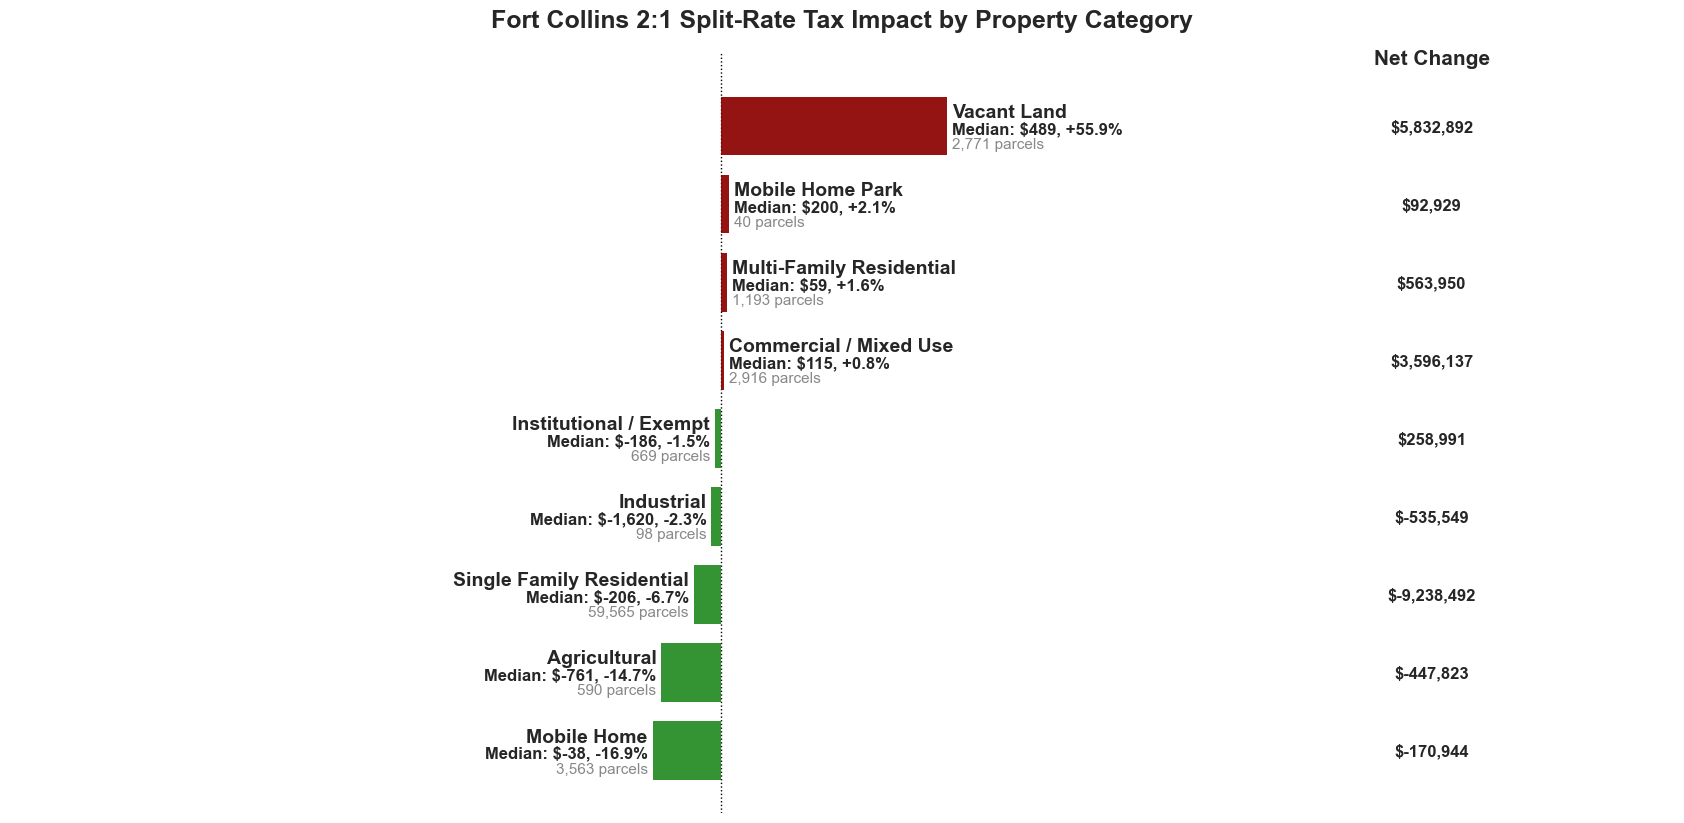

(<Figure size 1700x840 with 1 Axes>,
 <Axes: title={'center': 'Fort Collins 2:1 Split-Rate Tax Impact by Property Category'}>)

In [9]:
create_spokane_property_category_chart(
    category_summary,
    title="Fort Collins 2:1 Split-Rate Tax Impact by Property Category",
    min_count=25,
)


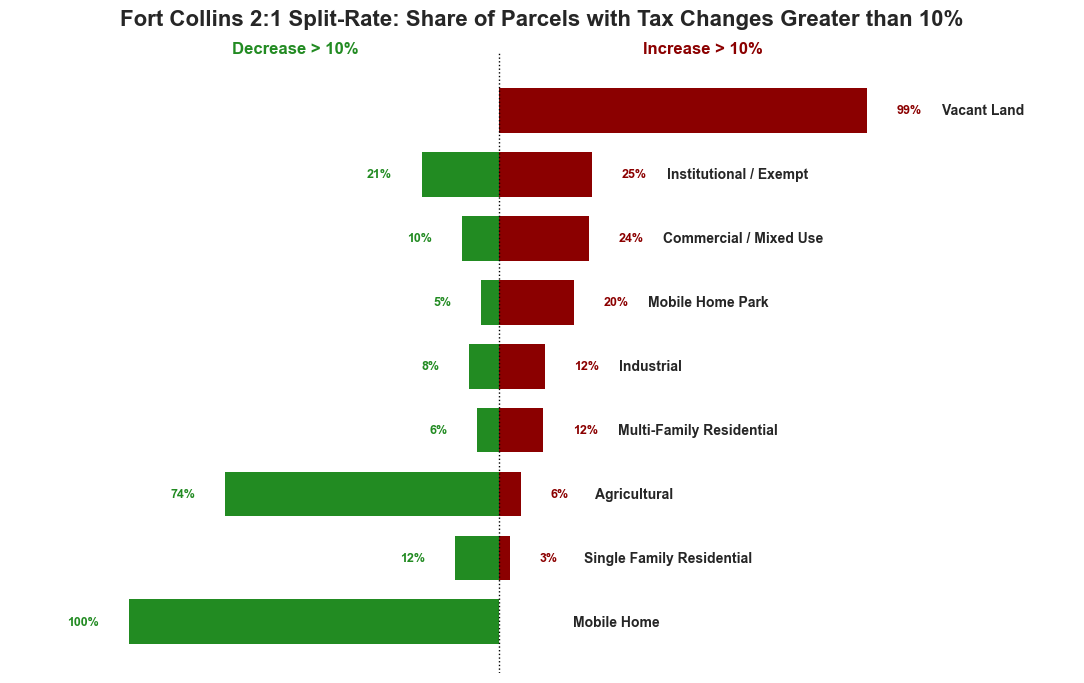

(<Figure size 1100x700 with 1 Axes>,
 <Axes: title={'center': 'Fort Collins 2:1 Split-Rate: Share of Parcels with Tax Changes Greater than 10%'}>)

In [10]:
create_threshold_change_chart(
    category_summary,
    title="Fort Collins 2:1 Split-Rate: Share of Parcels with Tax Changes Greater than 10%",
    threshold=10.0,
    min_count=25,
)


PROPERTY_CATEGORY,Commercial / Mixed Use,Industrial,Multi-Family Residential,Single Family Residential,Vacant Land
scenario,,,,,
Split-rate 2:1,0.790100,-2.315647,1.626123,-6.679678,55.942353
Split-rate 4:1,1.799396,-5.336060,3.796653,-15.520890,116.500470


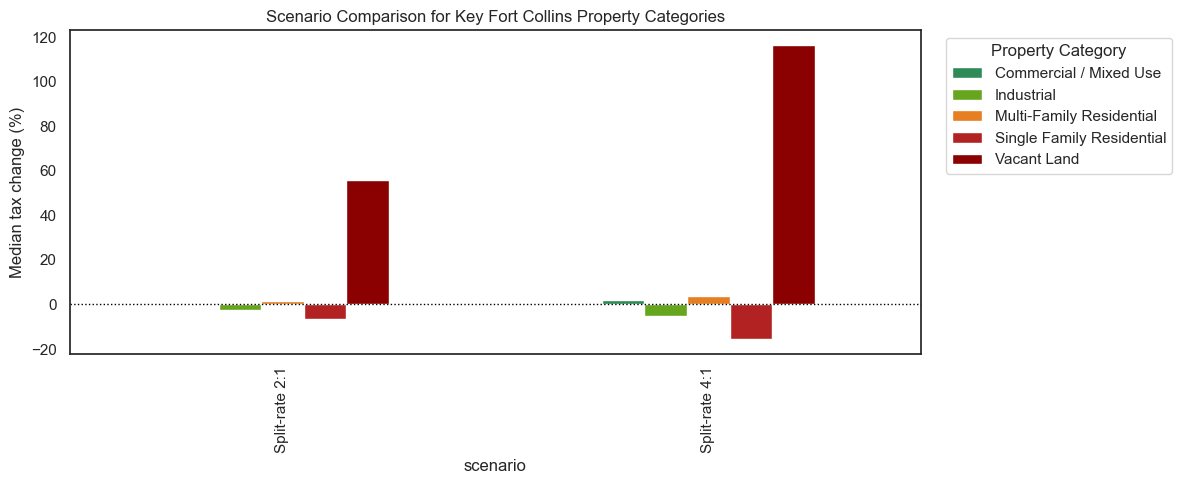

In [11]:
focus_categories = [
    "Single Family Residential",
    "Multi-Family Residential",
    "Commercial / Mixed Use",
    "Industrial",
    "Vacant Land",
]

scenario_rows = []
for scenario in scenarios:
    summary = scenario["category_summary"].copy()
    summary = summary[summary["PROPERTY_CATEGORY"].isin(focus_categories)]
    summary["scenario"] = scenario["scenario"]
    scenario_rows.append(summary[["scenario", "PROPERTY_CATEGORY", "median_tax_change_pct"]])

scenario_category_df = pd.concat(scenario_rows, ignore_index=True)
pivot = scenario_category_df.pivot(
    index="scenario",
    columns="PROPERTY_CATEGORY",
    values="median_tax_change_pct",
)
display(pivot)

fig, ax = plt.subplots(figsize=(12, 5))
pivot.plot(kind="bar", ax=ax, color=["#2E8B57", "#66A61E", "#E67E22", "#B22222", "#8B0000"])
ax.axhline(0, color="black", linestyle="dotted", linewidth=1)
ax.set_ylabel("Median tax change (%)")
ax.set_title("Scenario Comparison for Key Fort Collins Property Categories")
ax.legend(title="Property Category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


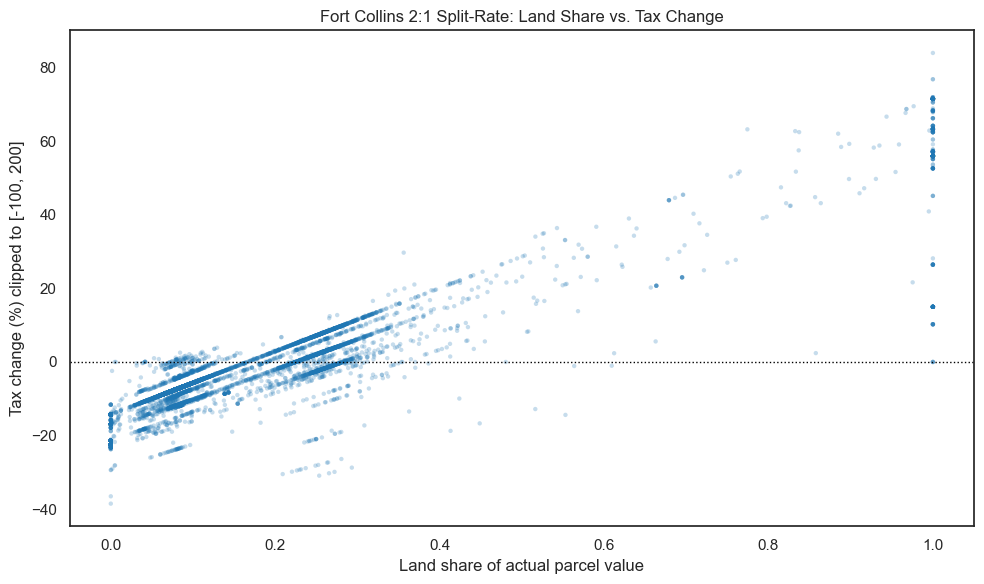

In [12]:
sample = fort_collins_2to1[
    (fort_collins_2to1["total_actual_value"] > 0) &
    np.isfinite(fort_collins_2to1["tax_change_pct"])
].copy()
if len(sample) > 8000:
    sample = sample.sample(8000, random_state=42)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(
    sample["land_share_actual"],
    sample["tax_change_pct"].clip(-100, 200),
    s=10,
    alpha=0.25,
    color="#1f77b4",
    edgecolors="none",
)
ax.axhline(0, color="black", linestyle="dotted", linewidth=1)
ax.set_xlabel("Land share of actual parcel value")
ax.set_ylabel("Tax change (%) clipped to [-100, 200]")
ax.set_title("Fort Collins 2:1 Split-Rate: Land Share vs. Tax Change")
plt.tight_layout()
plt.show()


## Step 6: Vacant Land and Underused-Land Diagnostics


In [13]:
vacant_results = analyze_vacant_land(
    fort_collins_2to1,
    land_value_col="land_actual_value",
    property_type_col="PROPERTY_CATEGORY",
    vacant_identifier="Vacant Land",
    improvement_value_col="improvement_actual_value",
)

print("Vacant parcels:", vacant_results.get("total_vacant_parcels"))
print("Total vacant land value:", vacant_results.get("total_vacant_land_value"))
print("Vacant land share of all city land value (%):", vacant_results.get("vacant_land_pct_of_total"))

top_vacant = fort_collins_2to1[fort_collins_2to1["PROPERTY_CATEGORY"] == "Vacant Land"].copy()
top_vacant = top_vacant.sort_values("land_actual_value", ascending=False)[
    ["SCHEDULENUM", "SITUSADDRESS", "TAXAREA", "land_actual_value", "current_tax", "new_tax", "tax_change"]
].head(10)
top_vacant


Vacant parcels: 2771
Total vacant land value: 449087060.0
Vacant land share of all city land value (%): 5.08867177682313


,SCHEDULENUM,SITUSADDRESS,TAXAREA,land_actual_value,current_tax,new_tax,tax_change
9826,145297,2388 W TRILBY RD,10168,27559810.0,716984.470746,798097.979096,81113.508350
5386,1609912,2080 NE FRONTAGE RD,1002,15201520.0,388022.712580,609675.392069,221652.679489
49743,1589140,0,1101,11767730.0,294623.468936,472709.165623,178085.696687
64116,145386,750 E VINE DR,1109,6109290.0,161203.117824,262390.078734,101186.960910
8650,1601183,2005 N OVERLAND TRL,10073,5503760.0,140484.886070,217898.422053,77413.535983
33888,664189,S TAFT HILL RD,1100,4865700.0,121820.389992,208900.432407,87080.042415
66564,1680389,0,1128,4436880.0,111084.249424,111084.249424,0.000000
64336,1685883,360 TENNEY CT,1109,4146100.0,36124.524180,58798.343792,22673.819612
13616,141305,CARPENTER RD,1100,4116420.0,103060.959224,176731.325089,73670.365865
10238,242713,4912 DEER TRAIL CT,1024,3872470.0,102002.379819,155653.940597,53651.560778


,TAXAREA,parcel_count,land_value,mean_tax_change
0,1100,528,92310640.0,2990.552029
1,11098,235,31010610.0,764.110603
2,10168,1,27559810.0,81113.508350
3,1002,180,25893870.0,2019.152204
4,1109,33,25791770.0,9600.561456
5,1108,682,23404110.0,474.006636
6,1107,156,19394690.0,1978.943828
7,1101,20,18774930.0,14155.266496
8,1024,101,15938920.0,2044.024719
9,1112,72,15365830.0,2930.340951


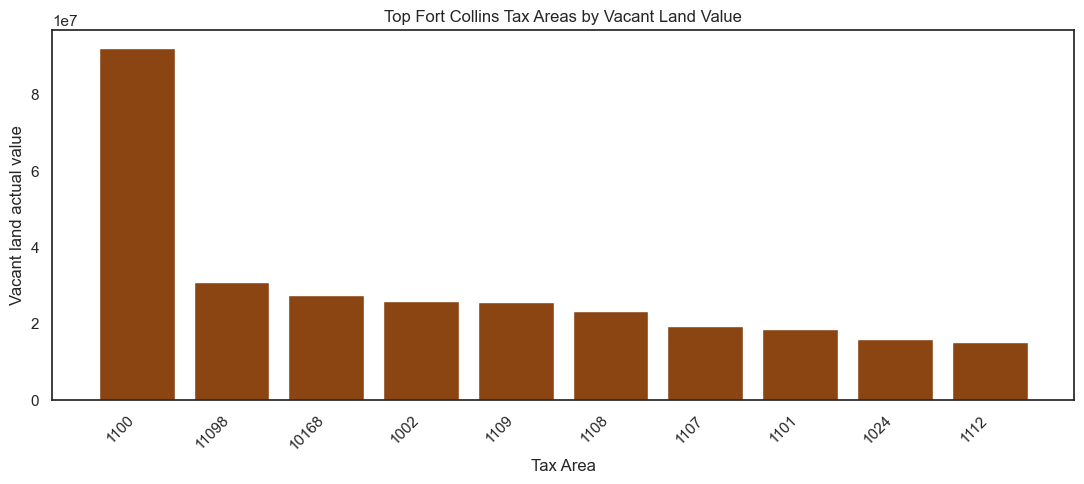

In [14]:
vacant_by_tax_area = (
    fort_collins_2to1[fort_collins_2to1["PROPERTY_CATEGORY"] == "Vacant Land"]
    .groupby("TAXAREA")
    .agg(
        parcel_count=("SCHEDULENUM", "count"),
        land_value=("land_actual_value", "sum"),
        mean_tax_change=("tax_change", "mean"),
    )
    .sort_values("land_value", ascending=False)
    .head(10)
    .reset_index()
)
display(vacant_by_tax_area)

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(vacant_by_tax_area["TAXAREA"].astype(str), vacant_by_tax_area["land_value"], color="#8B4513")
ax.set_title("Top Fort Collins Tax Areas by Vacant Land Value")
ax.set_xlabel("Tax Area")
ax.set_ylabel("Vacant land actual value")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [15]:
underused = analyze_land_by_improvement_share(
    fort_collins_2to1,
    land_value_col="land_actual_value",
    improvement_value_col="improvement_actual_value",
)

underused_df = pd.DataFrame(underused["categories"])
underused_df


,category,parcel_count,adjusted_land_value,share_of_total_land_value_pct
0,0% improvement,2771,449087060.0,5.088672
1,<10% improvement (excl. 0%),125,85829230.0,0.972544
2,10-25% improvement,172,108068500.0,1.224540
3,25-50% improvement,568,393508370.0,4.458901


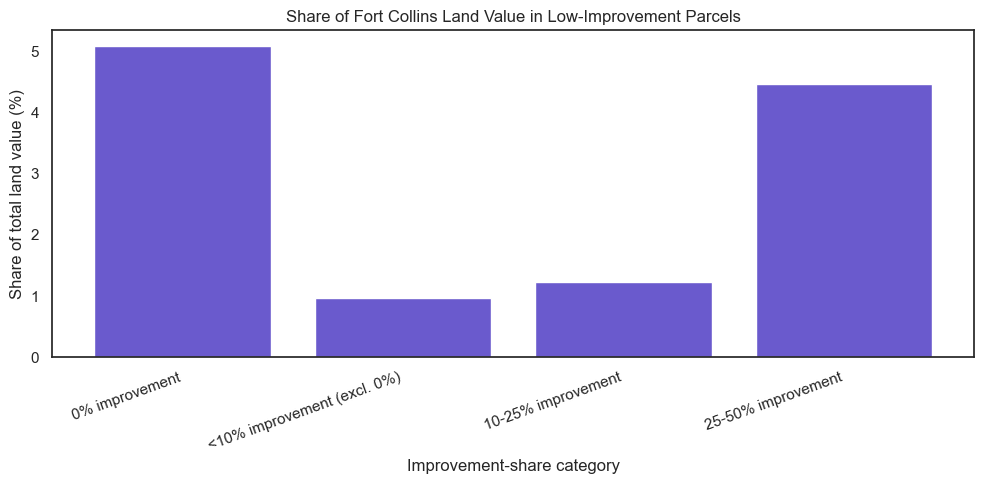

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(
    underused_df["category"],
    underused_df["share_of_total_land_value_pct"],
    color="#6A5ACD",
)
ax.set_title("Share of Fort Collins Land Value in Low-Improvement Parcels")
ax.set_ylabel("Share of total land value (%)")
ax.set_xlabel("Improvement-share category")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


## Step 7: Census Progressivity Analysis

This follows the stronger Cleveland / Spokane pattern, using parcel-level tax changes joined to Census block groups and then summarized into quintiles.


In [17]:
parcel_geo = gpd.read_file(GEOMETRY_URL)
parcel_geo["SCHEDNUM"] = pd.to_numeric(parcel_geo["SCHEDNUM"], errors="coerce")
if parcel_geo.crs is None:
    parcel_geo = parcel_geo.set_crs("EPSG:2876")
fort_collins_geo = parcel_geo[parcel_geo["SCHEDNUM"].isin(fc_sched)].copy()

fort_collins_geo = gpd.GeoDataFrame(
    fort_collins_geo.merge(
        fort_collins_2to1,
        left_on="SCHEDNUM",
        right_on="SCHEDULENUM",
        how="inner",
    ),
    geometry="geometry",
    crs=parcel_geo.crs,
)
fort_collins_geo = fort_collins_geo.to_crs(3857)

print(f"Geometry rows merged: {len(fort_collins_geo):,}")
fort_collins_geo[["SCHEDNUM", "LOCADDRESS", "PROPERTY_CATEGORY", "tax_change_pct"]].head()


Geometry rows merged: 71,438


,SCHEDNUM,LOCADDRESS,PROPERTY_CATEGORY,tax_change_pct
0,121410.0,2913 STOVER ST,Single Family Residential,-7.084590
1,121576.0,2918 STOVER ST,Single Family Residential,-7.597369
2,159832.0,5531 RIX RD,Single Family Residential,-12.726023
3,121738.0,700 OXFORD LN,Single Family Residential,-8.022204
4,1296108.0,9704 MINERS LAKE RD,Single Family Residential,57.761823


In [18]:
census_data, census_boundaries = get_census_data_with_boundaries("08069", year=2022)
if census_boundaries.crs is None:
    census_boundaries = census_boundaries.set_crs("EPSG:4326")
df_geo = match_to_census_blockgroups(fort_collins_geo, census_boundaries)

print(f"Parcels matched to Census block groups: {len(df_geo):,}")
df_geo[["std_geoid", "median_income", "minority_pct", "black_pct", "PROPERTY_CATEGORY", "tax_change_pct"]].head()


Parcels matched to Census block groups: 71,438


,std_geoid,median_income,minority_pct,black_pct,PROPERTY_CATEGORY,tax_change_pct
0,080690010031,54453.0,26.45,0.0,Single Family Residential,-7.084590
1,080690010033,90588.0,9.50,0.0,Single Family Residential,-7.597369
2,080690025082,102961.0,5.18,0.0,Single Family Residential,-12.726023
3,080690010033,90588.0,9.50,0.0,Single Family Residential,-8.022204
4,080690025032,96190.0,2.97,0.0,Single Family Residential,57.761823


In [19]:
gdf_filtered, non_vacant_gdf = filter_data_for_analysis(df_geo)

non_vacant_income_quintile_summary = create_quintile_summary(
    non_vacant_gdf,
    "median_income",
    "median_income",
)
non_vacant_minority_quintile_summary = create_quintile_summary(
    non_vacant_gdf,
    "minority_pct",
    "minority_pct",
)

residential_categories = [
    "Single Family Residential",
    "Multi-Family Residential",
    "Mobile Home",
    "Mobile Home Park",
]
non_vacant_residential_gdf = non_vacant_gdf[
    non_vacant_gdf["PROPERTY_CATEGORY"].isin(residential_categories)
].copy()

non_vacant_income_quintile_summary_res = create_quintile_summary(
    non_vacant_residential_gdf,
    "median_income",
    "median_income",
)
non_vacant_minority_quintile_summary_res = create_quintile_summary(
    non_vacant_residential_gdf,
    "minority_pct",
    "minority_pct",
)

print("Non-vacant income quintiles")
display(non_vacant_income_quintile_summary)
print("Non-vacant minority-share quintiles")
display(non_vacant_minority_quintile_summary)
print("Residential-only non-vacant income quintiles")
display(non_vacant_income_quintile_summary_res)
print("Residential-only non-vacant minority-share quintiles")
display(non_vacant_minority_quintile_summary_res)


/Users/gregmiller/Documents/CLE/cle/LVTShift/viz.py:269: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = work_df.groupby(f'{group_col}_quintile').apply(
/Users/gregmiller/Documents/CLE/cle/LVTShift/viz.py:269: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = work_df.groupby(f'{group_col}_quintile').apply(
/Users/gregmiller/Documents/CLE/cle/LVTShift/viz.py:269: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
 

Non-vacant income quintiles


/Users/gregmiller/Documents/CLE/cle/LVTShift/viz.py:269: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = work_df.groupby(f'{group_col}_quintile').apply(


,median_income_quintile,count,mean_tax_change_pct,median_tax_change_pct,mean_value
0,Q1 (Lowest),13596.0,-5.354744,-7.421481,49352.605693
1,Q2,13142.0,-4.698091,-6.682882,74351.589636
2,Q3,13332.0,-4.721753,-7.160338,91216.428218
3,Q4,13153.0,-3.755441,-5.706648,114565.518209
4,Q5 (Highest),13262.0,-3.028575,-5.250640,154750.904539


Non-vacant minority-share quintiles


,minority_pct_quintile,count,mean_tax_change_pct,median_tax_change_pct,mean_value
0,Q1 (Lowest),13655.0,-5.135330,-6.979863,7.987829
1,Q2,13710.0,-3.336810,-5.460599,13.757969
2,Q3,13196.0,-4.012566,-7.108538,17.683902
3,Q4,13512.0,-2.722034,-5.754368,24.858523
4,Q5 (Highest),12412.0,-6.562645,-7.366583,40.505827


Residential-only non-vacant income quintiles


,median_income_quintile,count,mean_tax_change_pct,median_tax_change_pct,mean_value
0,Q1 (Lowest),12790.0,-6.619993,-7.603188,50929.340344
1,Q2,12738.0,-5.375719,-6.869751,75804.073324
2,Q3,12235.0,-4.926641,-7.089038,92718.970740
3,Q4,12495.0,-3.284833,-5.216753,115944.257223
4,Q5 (Highest),12205.0,-3.486457,-5.672714,155557.534289


Residential-only non-vacant minority-share quintiles


,minority_pct_quintile,count,mean_tax_change_pct,median_tax_change_pct,mean_value
0,Q1 (Lowest),12869.0,-5.406977,-7.023404,8.058429
1,Q2,12891.0,-3.800795,-5.709734,13.803291
2,Q3,12398.0,-4.569186,-7.176976,17.664463
3,Q4,11812.0,-3.027735,-5.881956,24.531671
4,Q5 (Highest),12493.0,-6.886133,-7.353976,39.577533


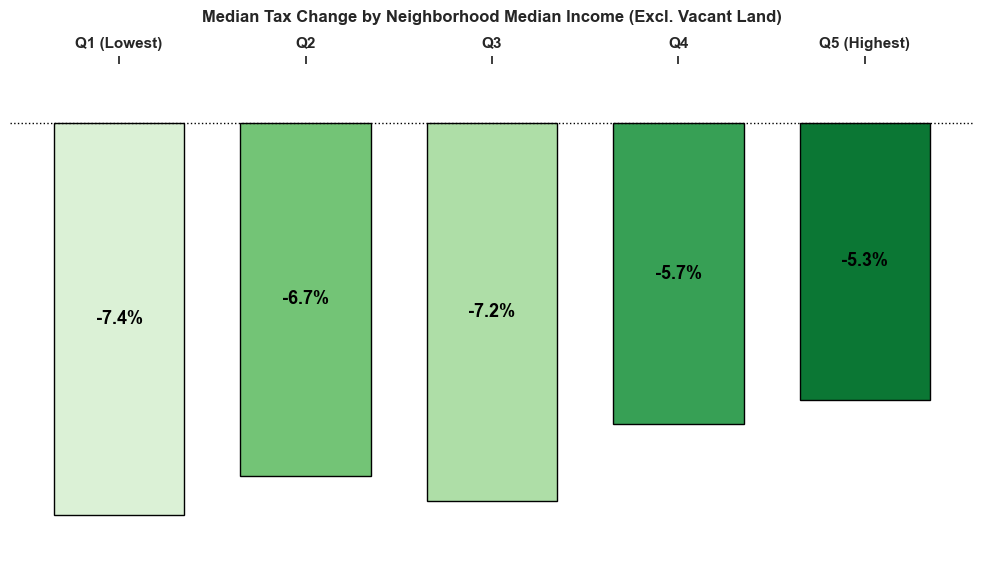

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Median Tax Change by Neighborhood Median Income (Excl. Vacant Land)'}>)

In [20]:
plot_upside_down_quintile_bars(
    non_vacant_income_quintile_summary,
    "Median Tax Change by Neighborhood Median Income (Excl. Vacant Land)",
)


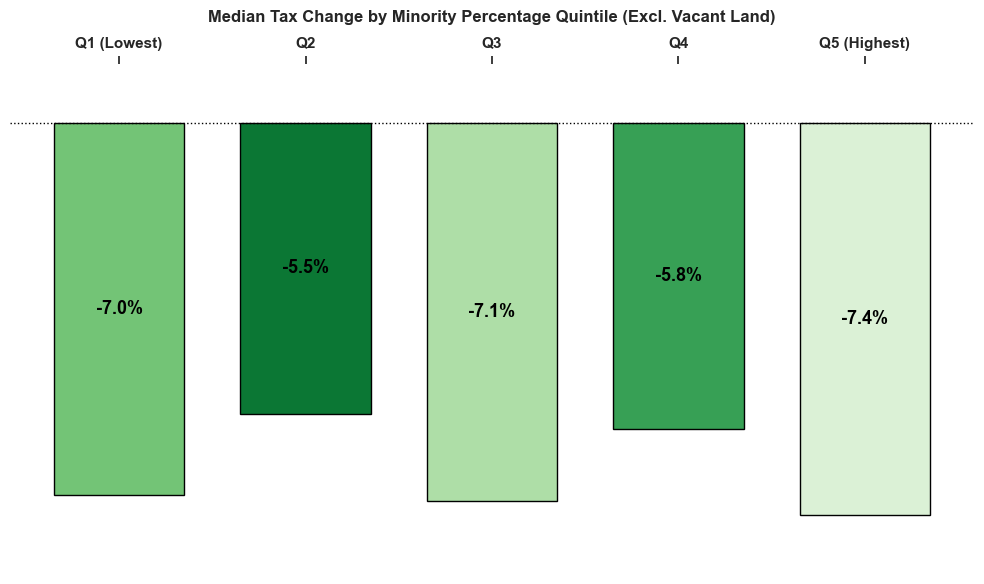

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Median Tax Change by Minority Percentage Quintile (Excl. Vacant Land)'}>)

In [21]:
plot_upside_down_quintile_bars(
    non_vacant_minority_quintile_summary,
    "Median Tax Change by Minority Percentage Quintile (Excl. Vacant Land)",
)


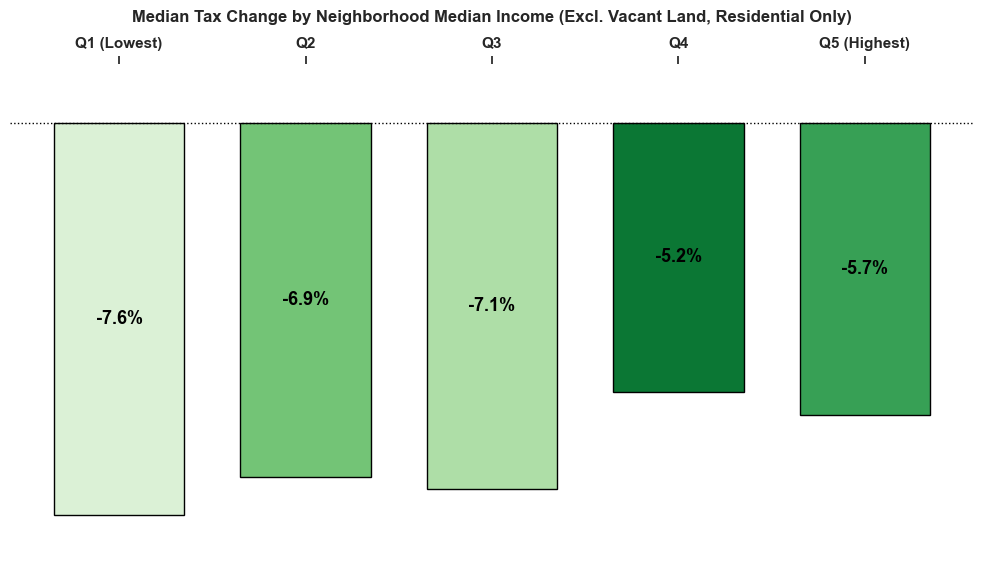

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Median Tax Change by Neighborhood Median Income (Excl. Vacant Land, Residential Only)'}>)

In [22]:
plot_upside_down_quintile_bars(
    non_vacant_income_quintile_summary_res,
    "Median Tax Change by Neighborhood Median Income (Excl. Vacant Land, Residential Only)",
)


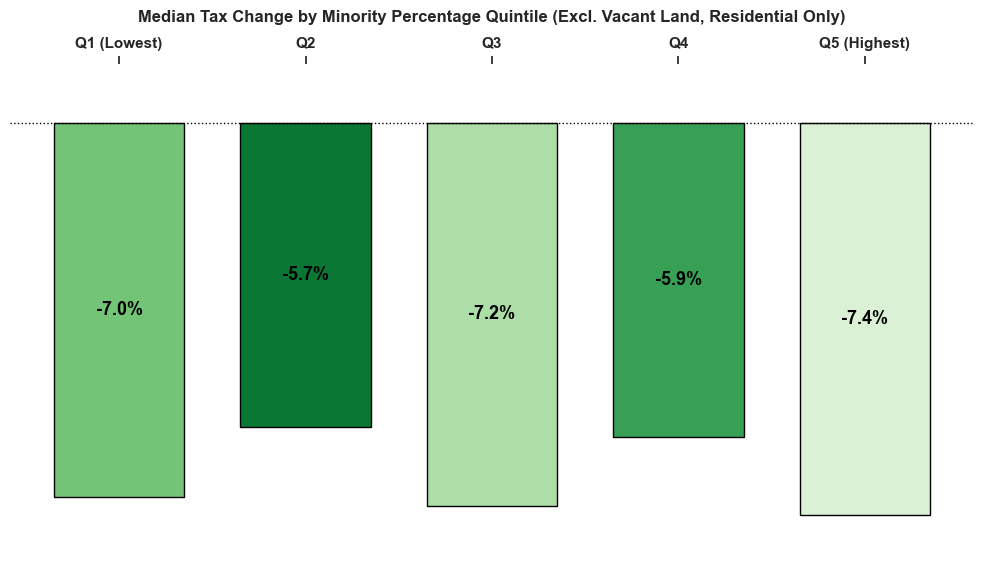

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Median Tax Change by Minority Percentage Quintile (Excl. Vacant Land, Residential Only)'}>)

In [23]:
plot_upside_down_quintile_bars(
    non_vacant_minority_quintile_summary_res,
    "Median Tax Change by Minority Percentage Quintile (Excl. Vacant Land, Residential Only)",
)


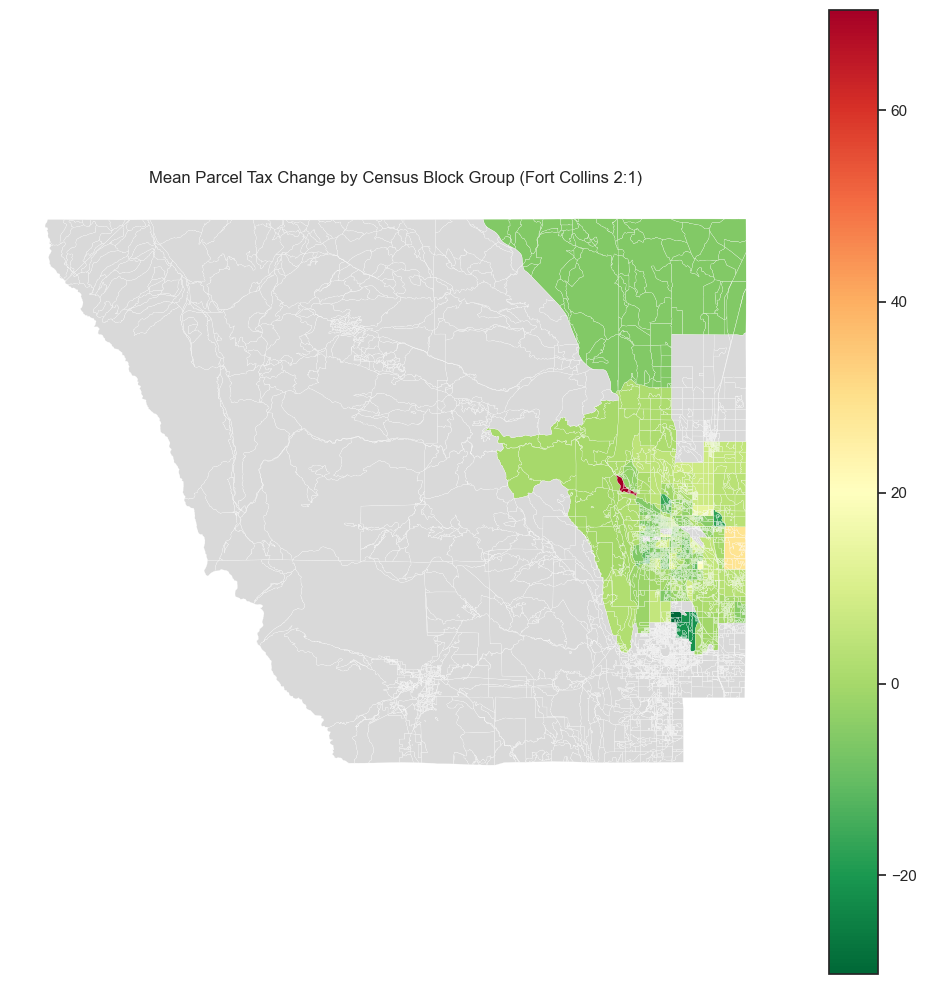

In [24]:
bg_summary = calculate_block_group_summary(df_geo)
bg_map = census_boundaries.merge(
    bg_summary[["std_geoid", "mean_tax_change_pct", "median_income", "minority_pct", "parcel_count"]],
    on="std_geoid",
    how="left",
)

fig, ax = plt.subplots(figsize=(10, 10))
bg_map.plot(
    column="mean_tax_change_pct",
    cmap="RdYlGn_r",
    linewidth=0.15,
    edgecolor="white",
    legend=True,
    ax=ax,
    missing_kwds={"color": "#d9d9d9", "label": "No data"},
)
ax.set_title("Mean Parcel Tax Change by Census Block Group (Fort Collins 2:1)")
ax.set_axis_off()
plt.tight_layout()
plt.show()


## Step 8: Adding Geographic Context

Fort Collins parcel geometry comes from Larimer County's public `GIS_ParcelOwnerSHP.zip` download.


In [25]:
fort_collins_geo[["SCHEDNUM", "LOCADDRESS", "PROPERTY_CATEGORY", "tax_change_pct"]].head()


,SCHEDNUM,LOCADDRESS,PROPERTY_CATEGORY,tax_change_pct
0,121410.0,2913 STOVER ST,Single Family Residential,-7.084590
1,121576.0,2918 STOVER ST,Single Family Residential,-7.597369
2,159832.0,5531 RIX RD,Single Family Residential,-12.726023
3,121738.0,700 OXFORD LN,Single Family Residential,-8.022204
4,1296108.0,9704 MINERS LAKE RD,Single Family Residential,57.761823


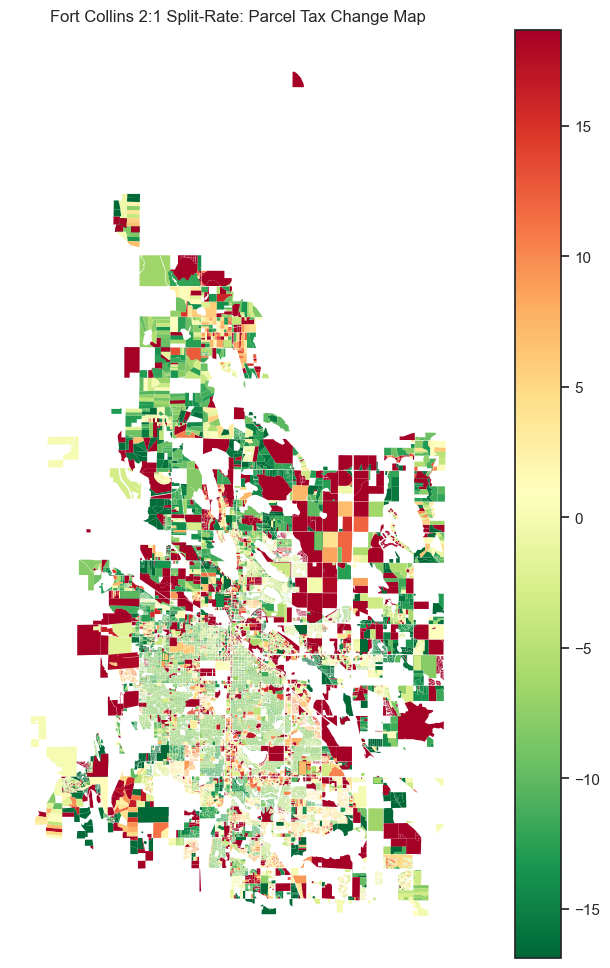

In [26]:
map_df = fort_collins_geo.copy()
lo = map_df["tax_change_pct"].quantile(0.05)
hi = map_df["tax_change_pct"].quantile(0.95)
map_df["map_tax_change_pct"] = map_df["tax_change_pct"].clip(lo, hi)

fig, ax = plt.subplots(figsize=(10, 10))
map_df.plot(
    column="map_tax_change_pct",
    cmap="RdYlGn_r",
    linewidth=0,
    legend=True,
    ax=ax,
)
ax.set_title("Fort Collins 2:1 Split-Rate: Parcel Tax Change Map")
ax.set_axis_off()
plt.tight_layout()
plt.show()


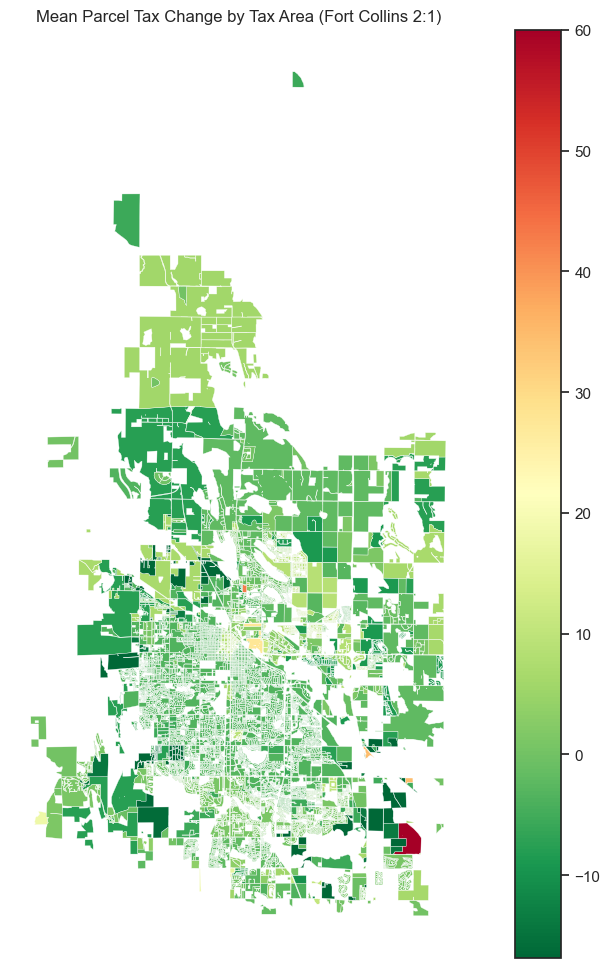

In [27]:
taxarea_geo = fort_collins_geo.dissolve(
    by="TAXAREA",
    aggfunc={
        "tax_change_pct": "mean",
        "current_tax": "sum",
        "new_tax": "sum",
    },
).reset_index()

fig, ax = plt.subplots(figsize=(10, 10))
taxarea_geo.plot(
    column="tax_change_pct",
    cmap="RdYlGn_r",
    linewidth=0.25,
    edgecolor="white",
    legend=True,
    ax=ax,
)
ax.set_title("Mean Parcel Tax Change by Tax Area (Fort Collins 2:1)")
ax.set_axis_off()
plt.tight_layout()
plt.show()
